In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Ingestion

In [ ]:
df = pd.read_csv("/content/Merged_Annually_Quarterly.csv")
df.head()

,base_year,series,year,indicator,frequency,revision,industry,subindustry,institutional_sector,quarter,current_price,constant_price,unit
0,2011-12,Current,2011-12,Gross Value Added,Annual,Second Revised Estimates,NaN,NaN,Public Non-Financial Corporations,NaN,624376.000,NaN,₹ Crore
1,2011-12,Current,2011-12,Gross Value Added,Annual,Second Revised Estimates,NaN,NaN,Private Non-Financial Corporations,NaN,2518493.000,NaN,₹ Crore
2,2011-12,Current,2011-12,Gross Value Added,Annual,Second Revised Estimates,NaN,NaN,Public Financial Corporations,NaN,249802.000,NaN,₹ Crore
3,2011-12,Current,2011-12,Gross Value Added,Annual,Second Revised Estimates,NaN,NaN,Private Financial Corporations,NaN,230424.000,NaN,₹ Crore
4,2011-12,Current,2022-23,Gross Fixed Capital Formation,Annual,Final Estimates,NaN,NaN,Household Sector,NaN,3598246.537,2262238.644,₹ Crore


In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
df.rename(columns={'ï»¿base_year': 'base_year'}, inplace=True)

Drop Duplicates

In [ ]:
df.duplicated().sum()

np.int64(57)

In [ ]:
df.drop_duplicates(inplace=True)

Split the dataset based on frequency

In [ ]:
annual_df = df[df['frequency'] == 'Annual'].copy()
quarterly_df = df[df['frequency'] == 'Quarterly'].copy()

Removing unnecessary columns

In [ ]:
annual_df.drop(['frequency', 'series', 'quarter'], axis=1, inplace=True)
quarterly_df.drop(['frequency','revision', 'series','subindustry','institutional_sector'], axis=1, inplace=True)

In [ ]:
annual_df.head()

,base_year,year,indicator,revision,industry,subindustry,institutional_sector,current_price,constant_price,unit
0,2011-12,2011-12,Gross Value Added,Second Revised Estimates,NaN,NaN,Public Non-Financial Corporations,624376.000,NaN,₹ Crore
1,2011-12,2011-12,Gross Value Added,Second Revised Estimates,NaN,NaN,Private Non-Financial Corporations,2518493.000,NaN,₹ Crore
2,2011-12,2011-12,Gross Value Added,Second Revised Estimates,NaN,NaN,Public Financial Corporations,249802.000,NaN,₹ Crore
3,2011-12,2011-12,Gross Value Added,Second Revised Estimates,NaN,NaN,Private Financial Corporations,230424.000,NaN,₹ Crore
4,2011-12,2022-23,Gross Fixed Capital Formation,Final Estimates,NaN,NaN,Household Sector,3598246.537,2262238.644,₹ Crore


In [ ]:
quarterly_df.head()

,base_year,year,indicator,industry,quarter,current_price,constant_price,unit
76,2011-12,2011-12,Gross Value Added,"Agriculture, Livestock, Forestry and Fishing",Q3,505545.33890,500965.57540,₹ Crore
77,2011-12,2011-12,Gross Value Added,"Agriculture, Livestock, Forestry and Fishing",Q4,402948.88450,395797.54560,₹ Crore
78,2011-12,2011-12,Gross Value Added,"Agriculture, Livestock, Forestry and Fishing",Q1,323221.71640,336108.83790,₹ Crore
79,2011-12,2011-12,Gross Value Added,"Agriculture, Livestock, Forestry and Fishing",Q2,270231.38210,269074.12080,₹ Crore
80,2011-12,2011-12,Gross Value Added,Mining and Quarrying,Q4,75087.31079,71346.27384,₹ Crore


Apply Revision Priority

In [ ]:
annual_df['revision'].value_counts()

,count
revision,
First Revised Estimates,1447
Second Revised Estimates,1350
Third Revised Estimates,1119
Additional Revision,482
First Advance Estimates,373
Final Estimates,367
Provisional Estimates,341
Second Advance Estimates,310


In [ ]:
priority_order = {'Additional Revision': 1, 'Final Estimates': 2, 'Third Revised Estimates': 3, 'Second Revised Estimates': 4, 'First Revised Estimates': 5,
                  'Provisional Estimates': 6, 'Second Advance Estimates': 7, 'First Advance Estimates': 8}
annual_df['revision_rank'] = annual_df['revision'].map(priority_order)
annual_df = annual_df.sort_values(by=['year','indicator','industry','subindustry','institutional_sector','revision_rank'])
annual_df = annual_df.drop_duplicates(subset=['year','indicator','industry','subindustry','institutional_sector'],keep='first')

In [ ]:
annual_df.head()

,base_year,year,indicator,revision,industry,subindustry,institutional_sector,current_price,constant_price,unit,revision_rank
4106,2011-12,1999,Gross National Disposable Income,First Advance Estimates,NaN,NaN,NaN,3.620479e+07,NaN,₹ Crore,8
3681,2011-12,2011-12,Change in Stock,Additional Revision,NaN,NaN,NaN,2.079832e+05,207983.1878,₹ Crore,1
2183,2011-12,2011-12,Consumption of Fixed Capital,Additional Revision,NaN,NaN,General Government,9.862287e+04,NaN,₹ Crore,1
2184,2011-12,2011-12,Consumption of Fixed Capital,Additional Revision,NaN,NaN,Households Including NPISH,3.264252e+05,NaN,₹ Crore,1
2182,2011-12,2011-12,Consumption of Fixed Capital,Additional Revision,NaN,NaN,Private Financial Corporations,3.620414e+03,NaN,₹ Crore,1


In [ ]:
annual_df['revision'].value_counts()

,count
revision,
Third Revised Estimates,917
Additional Revision,362
Final Estimates,271
First Revised Estimates,137
Second Revised Estimates,131
Provisional Estimates,62
Second Advance Estimates,31
First Advance Estimates,2


Remove Aggregated Categories and illogical columns

In [ ]:
annual_df = annual_df[annual_df['institutional_sector'] != 'Total Gross Value Added']

In [ ]:
annual_df = annual_df[annual_df['industry'] != 'Total Gross Value Added']

In [ ]:
annual_df = annual_df[annual_df['industry'] != 'Total Gross Capital Formation']

In [ ]:
annual_df = annual_df[annual_df['year'] != '1999']

In [ ]:
annual_df = annual_df[annual_df['institutional_sector'] != 'Total Gross Saving']

In [ ]:
annual_df = annual_df[annual_df['institutional_sector'] != 'Total Consumption of Fixed Capital']

In [ ]:
annual_df = annual_df[annual_df['institutional_sector'] != 'Total Gross Fixed Capital Formation']

In [ ]:
annual_df = annual_df[annual_df['institutional_sector'] != 'Current']

Feature Engineering

1. Inflation Effect

In [ ]:
annual_df['inflation_effect'] = (annual_df['current_price'] - annual_df['constant_price'])
quarterly_df['inflation_effect'] = (quarterly_df['current_price'] - quarterly_df['constant_price'])

Indicator Analysis

GDP Trend Analysis

In [ ]:
gdp_df = annual_df[annual_df['indicator'] == 'Gross Domestic Product']
gva_df = annual_df[annual_df['indicator'] == 'Gross Value Added']

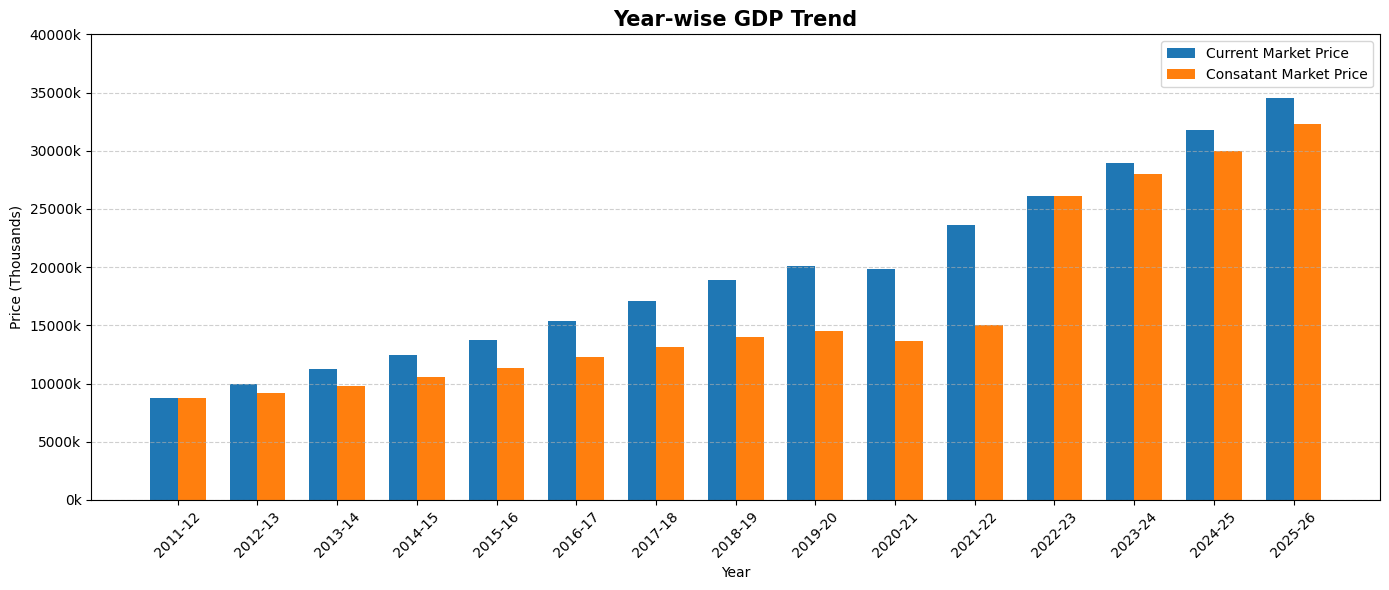

In [ ]:
x = np.arange(len(gdp_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, gdp_df['current_price'], width, label='Current Market Price')
plt.bar(x + width/2, gdp_df['constant_price'], width, label='Consatant Market Price')
plt.xticks(x, gdp_df ['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Year-wise GDP Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
gdp_growth_rate_df = annual_df[annual_df['indicator'] == 'GDP Growth Rate']

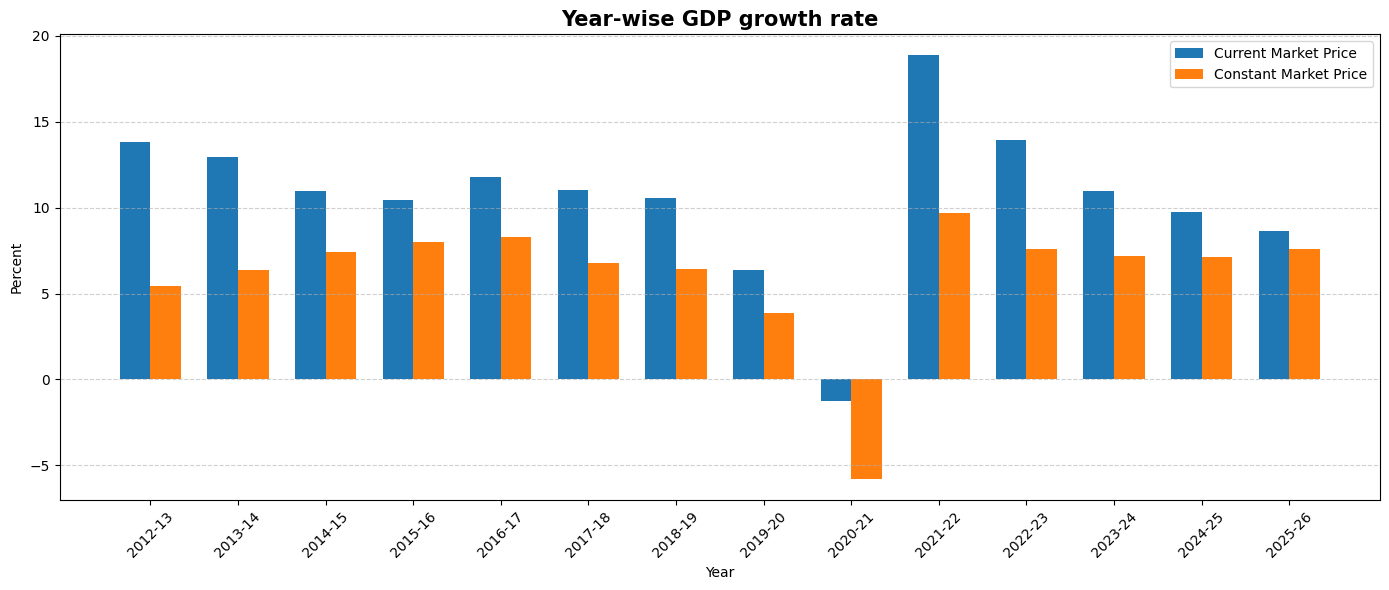

In [ ]:
x = np.arange(len(gdp_growth_rate_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, gdp_growth_rate_df['current_price'], width, label='Current Market Price')
plt.bar(x + width/2, gdp_growth_rate_df['constant_price'], width, label='Constant Market Price')
plt.xticks(x, gdp_growth_rate_df['year'], rotation=45)

plt.title("Year-wise GDP growth rate", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Percent")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The increase in GDP alongside declining growth rates post-pandemic is primarily driven by the base effect. The sharp contraction during the pandemic created a low base, resulting in elevated growth during recovery. As the economy stabilizes, growth rates normalize, even though the absolute GDP continues to rise.

Change in Stock Analysis

In [ ]:
change_in_stock_df = annual_df[annual_df['indicator'] == 'Change in Stock']

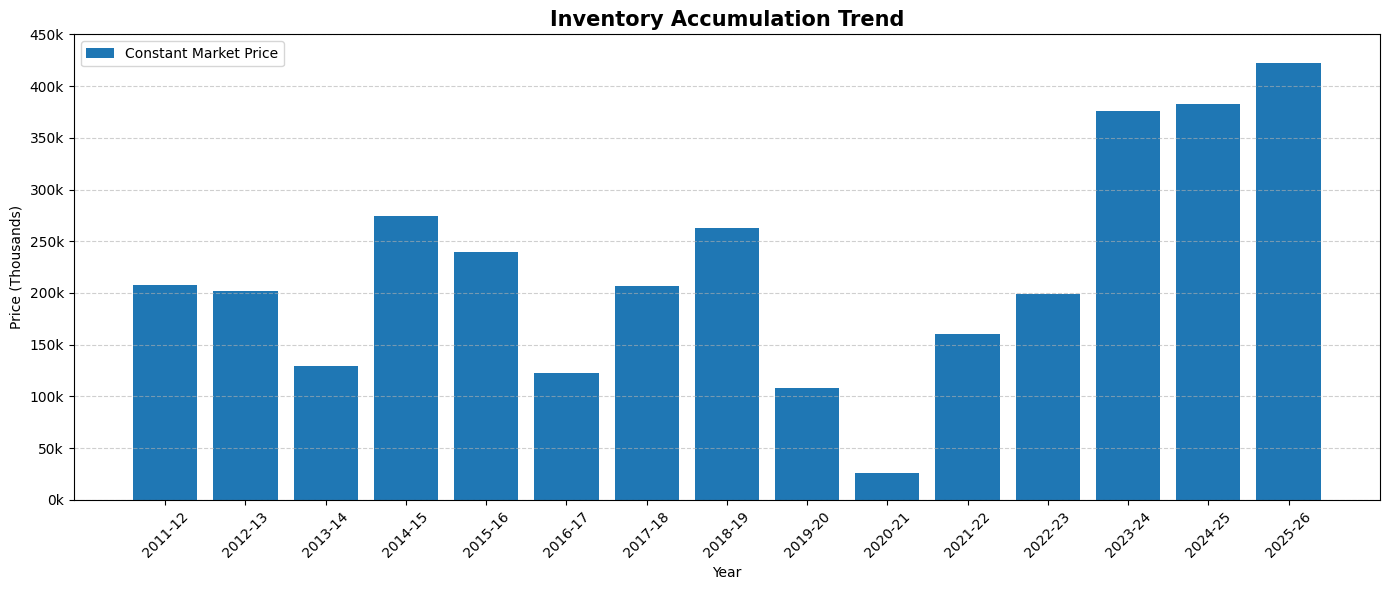

In [ ]:
x = np.arange(len(change_in_stock_df['year']))
plt.figure(figsize=(14,6))
plt.bar(x, change_in_stock_df['constant_price'], label='Constant Market Price')
plt.xticks(x, gdp_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Inventory Accumulation Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The volatility in change in stock indicates cyclical demand-supply imbalances, with a sharp contraction during 2020-21 followed by recovery, suggesting post-pandemic normalization of production and inventory levels

Tax analysis

In [ ]:
tax_on_products_df = annual_df[annual_df['indicator'] == 'Taxes on Products']

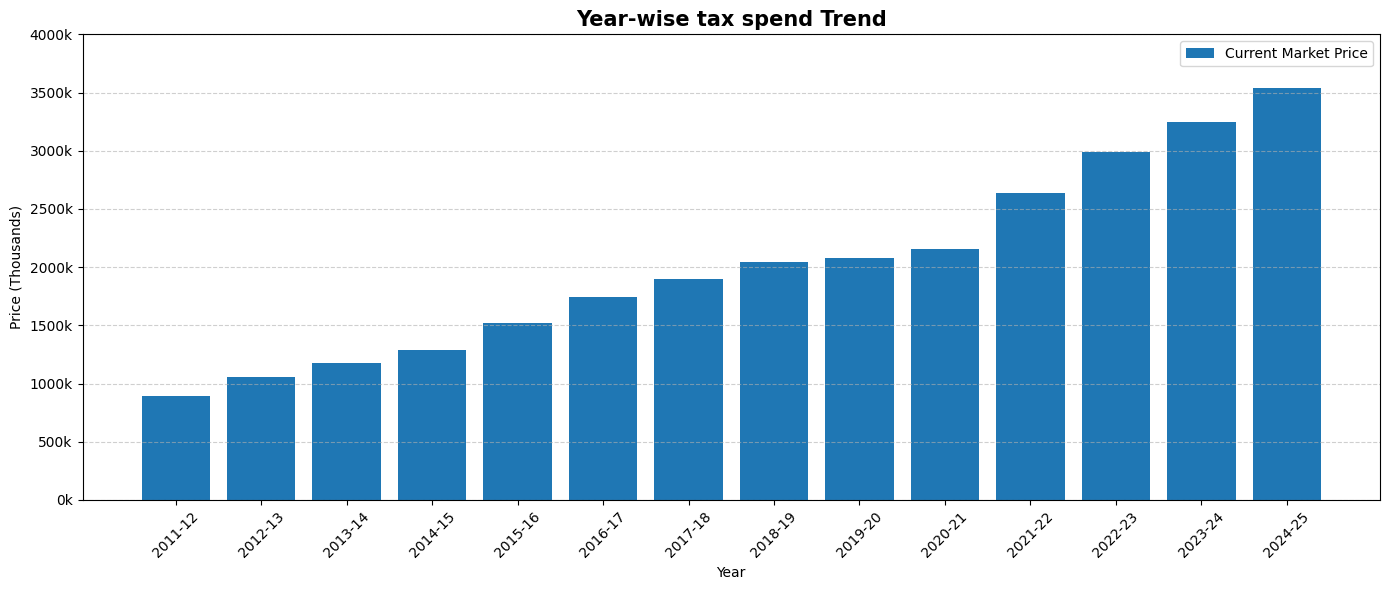

In [ ]:
x = np.arange(len(tax_on_products_df['year']))
plt.figure(figsize=(14,6))
plt.bar(x, tax_on_products_df['current_price'], label='Current Market Price')
plt.xticks(x, tax_on_products_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.title("Year-wise tax spend Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The upward trend in tax on products reflects increasing government revenue driven by both economic expansion and policy reforms such as GST, though part of the growth may be attributed to inflation

Subsidies analysis

In [ ]:
subsidies_on_products_df = annual_df[annual_df['indicator'] == 'Subsidies on Products']

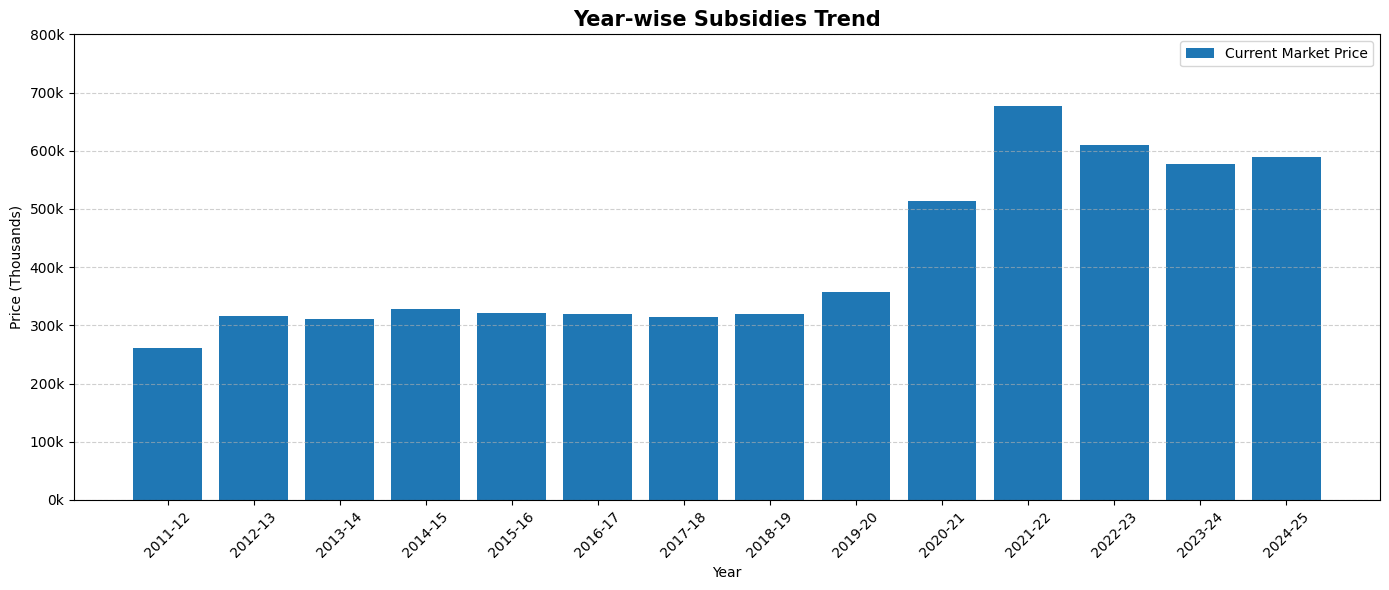

In [ ]:
x = np.arange(len(subsidies_on_products_df['year']))
plt.figure(figsize=(14,6))
plt.bar(x, subsidies_on_products_df['current_price'], label='Current Market Price')
plt.xticks(x, subsidies_on_products_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.title("Year-wise Subsidies Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Rising trend between 2019-2022 period, indicates increased government intervention to stabilize prices or support key sectors.

Valuable analysis

In [ ]:
valueables_df = annual_df[annual_df['indicator'] == 'Valuables']

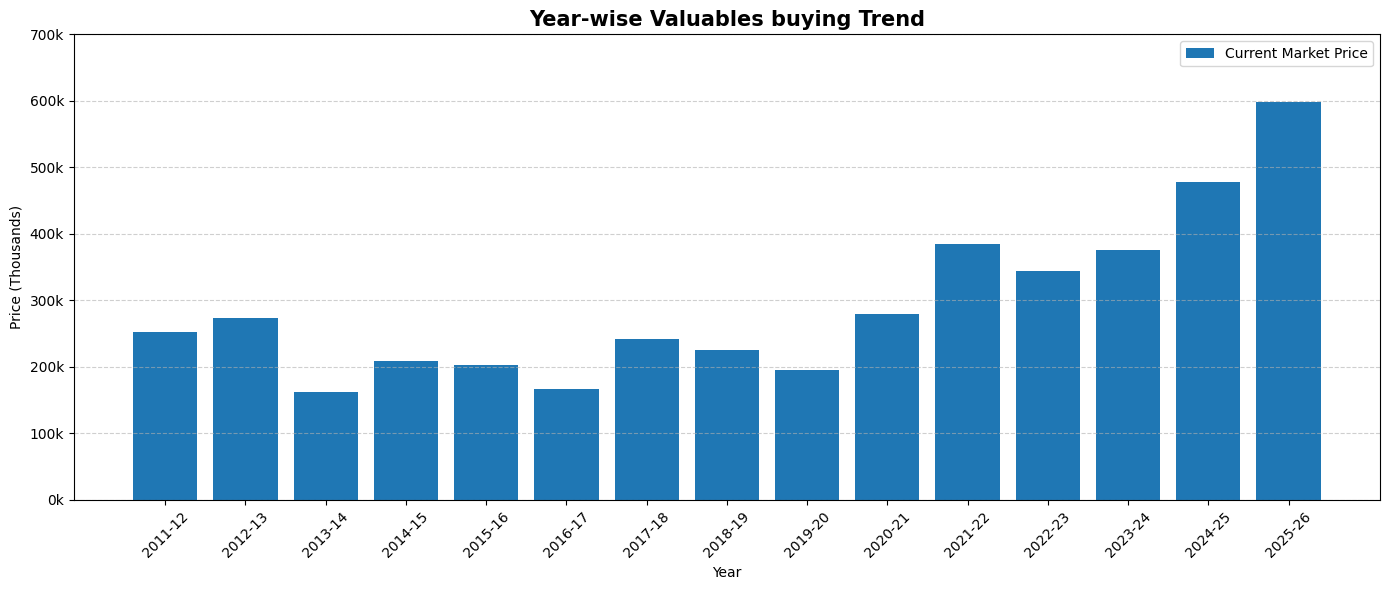

In [ ]:
x = np.arange(len(valueables_df['year']))
plt.figure(figsize=(14,6))
plt.bar(x, valueables_df['current_price'], label='Current Market Price')
plt.xticks(x, valueables_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.title("Year-wise Valuables buying Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

An increase in investment in valuables alongside declining GDP growth suggests a shift towards risk-averse behavior and capital allocation into non-productive assets, reflecting reduced economic confidence and potentially constraining future growth.

Import analysis

In [ ]:
import_of_goods_and_services_df = annual_df[annual_df['indicator'] == 'Import of Goods and Services']

In [ ]:
export_of_goods_and_services_df = annual_df[annual_df['indicator'] == 'Export of Goods and Services']

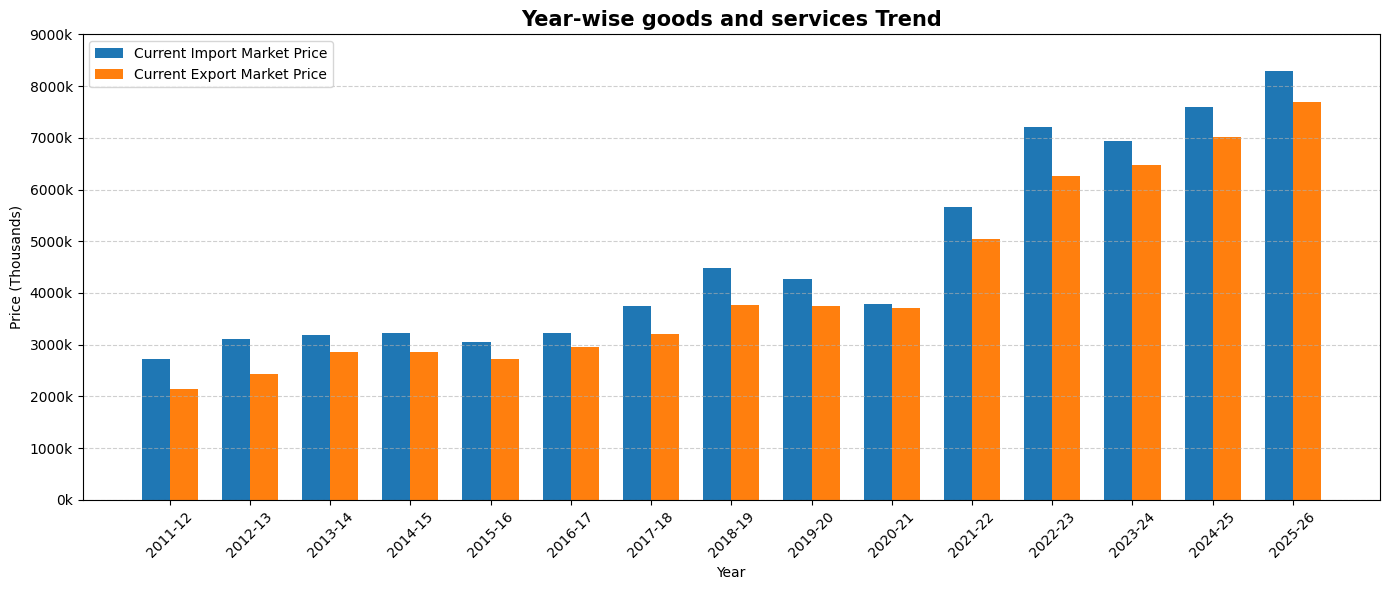

In [ ]:
x = np.arange(len(import_of_goods_and_services_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, import_of_goods_and_services_df['current_price'], width, label='Current Import Market Price')
plt.bar(x + width/2, export_of_goods_and_services_df['current_price'], width, label='Current Export Market Price')
plt.xticks(x, import_of_goods_and_services_df ['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Year-wise goods and services Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Imports consistently exceed exports, indicating a structural trade deficit. Overall both increasing which tells us Expanding economy through more global integration and higher demand & supply.

Private final consumption expenditure analysis

In [ ]:
private_final_consumption_expenditure_df = annual_df[annual_df['indicator'] == 'Private Final Consumption Expenditure']

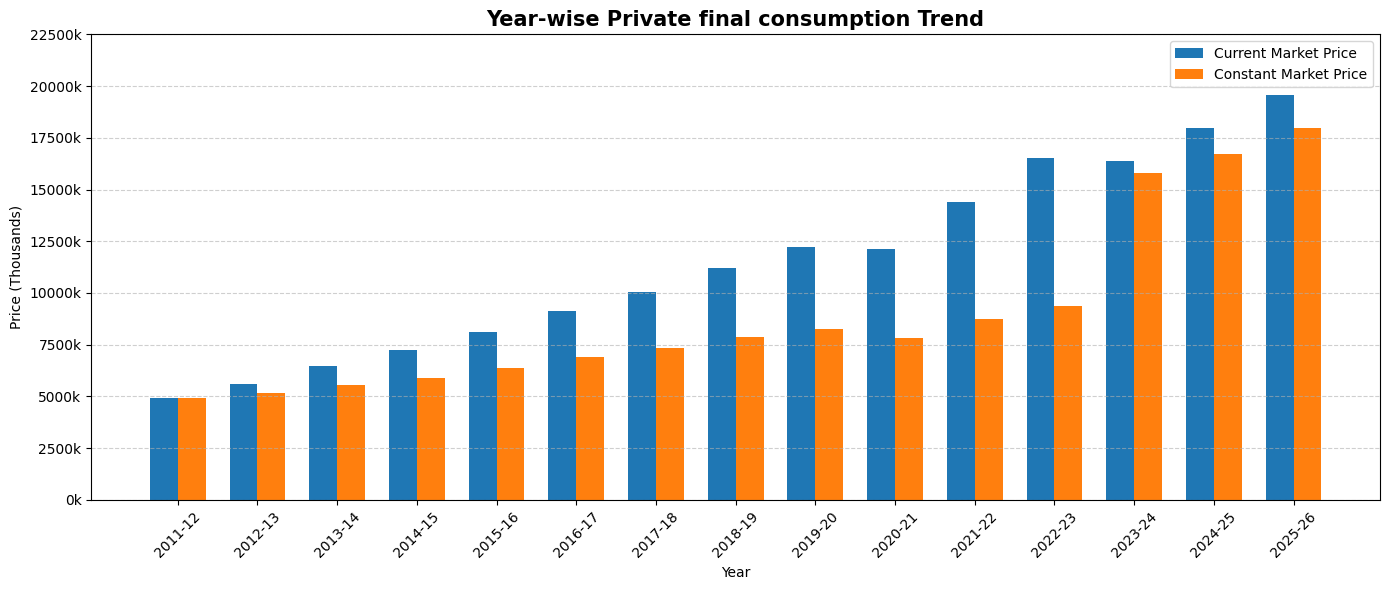

In [ ]:
x = np.arange(len(private_final_consumption_expenditure_df['year']))
plt.figure(figsize=(14,6))
plt.bar(x - width/2, private_final_consumption_expenditure_df['current_price'], width, label='Current Market Price')
plt.bar(x + width/2, private_final_consumption_expenditure_df['constant_price'], width, label='Constant Market Price')
plt.xticks(x, private_final_consumption_expenditure_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.title("Year-wise Private final consumption Trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Increasing PFCE meaning consumers are spending more and demand is strong. Economic Signal, Growth is demand-driven

Government final consumption expenditure analysis

In [ ]:
government_final_consumption_expenditure_df = annual_df[annual_df['indicator'] == 'Government Final Consumption Expenditure']

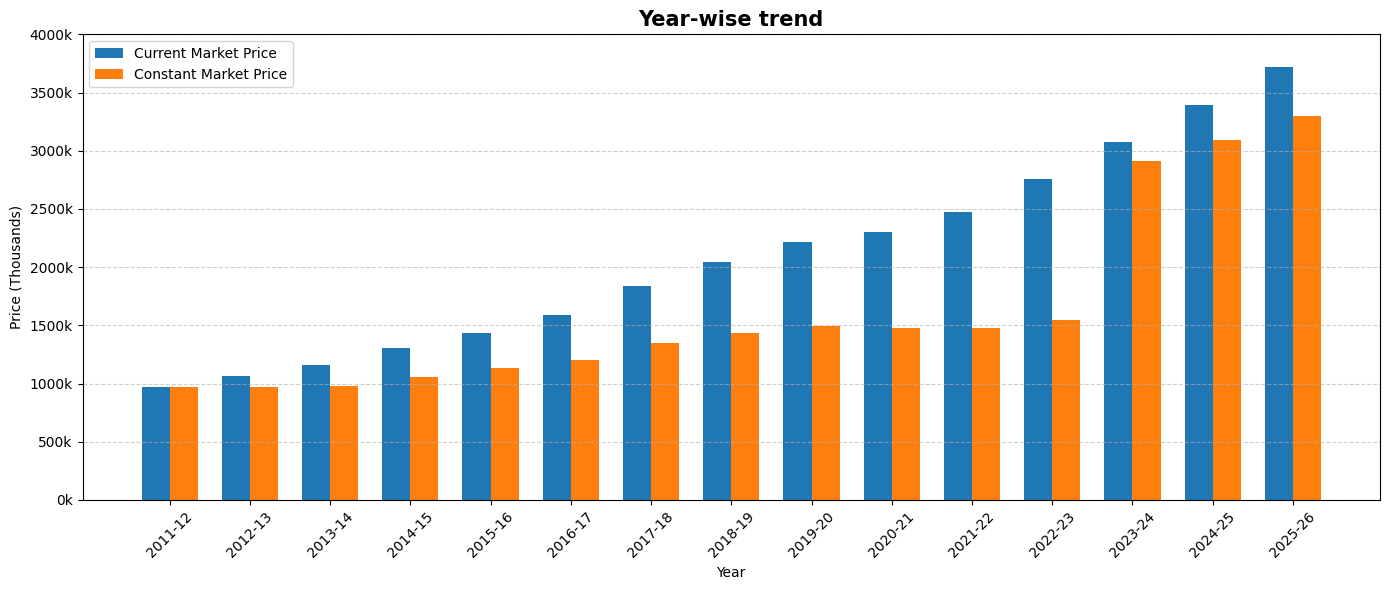

In [ ]:
x = np.arange(len(government_final_consumption_expenditure_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, government_final_consumption_expenditure_df['current_price'], width, label='Current Market Price')
plt.bar(x + width/2, government_final_consumption_expenditure_df['constant_price'], width, label='Constant Market Price')
plt.xticks(x, government_final_consumption_expenditure_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Year-wise trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Increasing Trend means government spending is rising. This can be interpretated as more investment in public services and expansionary fiscal policy. From 2017 - 2023, current market price is increasing and constant market price is flat, which means increase in current market price is inflation driven.This suggests that higher costs—such as wages, materials, or general price levels—are inflating the total value, rather than any meaningful expansion in real activity. From an analytical standpoint, this is a signal of price pressure without improvement in real output or service delivery.  After 2023 both are increasing, implies that the economy (or government spending, in the case of GFCE) is not only expanding in value but also in actual volume, indicating true economic progress rather than inflation-driven growth


Net Domestic product analysis

In [ ]:
net_domestic_product_df = annual_df[annual_df['indicator'] == 'Net Domestic Product']

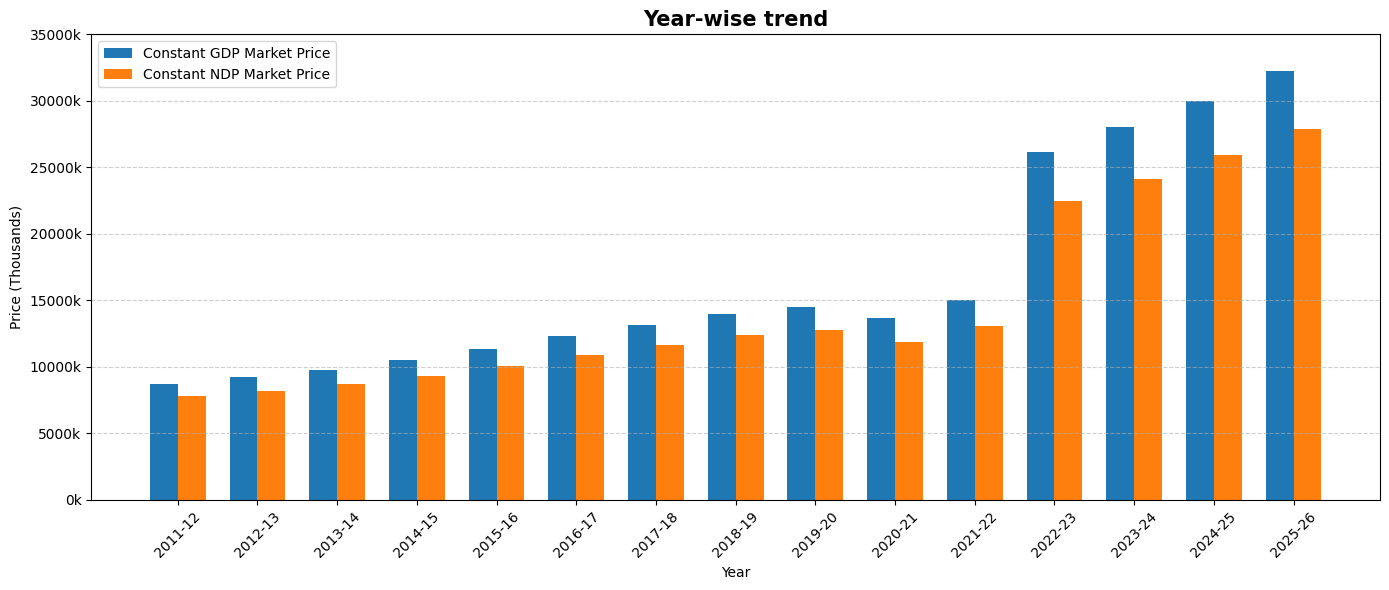

In [ ]:
x = np.arange(len(net_domestic_product_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, gdp_df['constant_price'], width, label='Constant GDP Market Price')
plt.bar(x + width/2, net_domestic_product_df['constant_price'], width, label='Constant NDP Market Price')
plt.xticks(x, net_domestic_product_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Year-wise trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Although GDP shows strong growth, the comparatively slower growth in NDP indicates rising depreciation, suggesting that a significant portion of output is being consumed in maintaining existing capital rather than generating net economic value.

Primary Income Receivable trend analysis

In [ ]:
primary_income_receivable_df = annual_df[annual_df['indicator'] == 'Primary Income Receivable Net From Row']

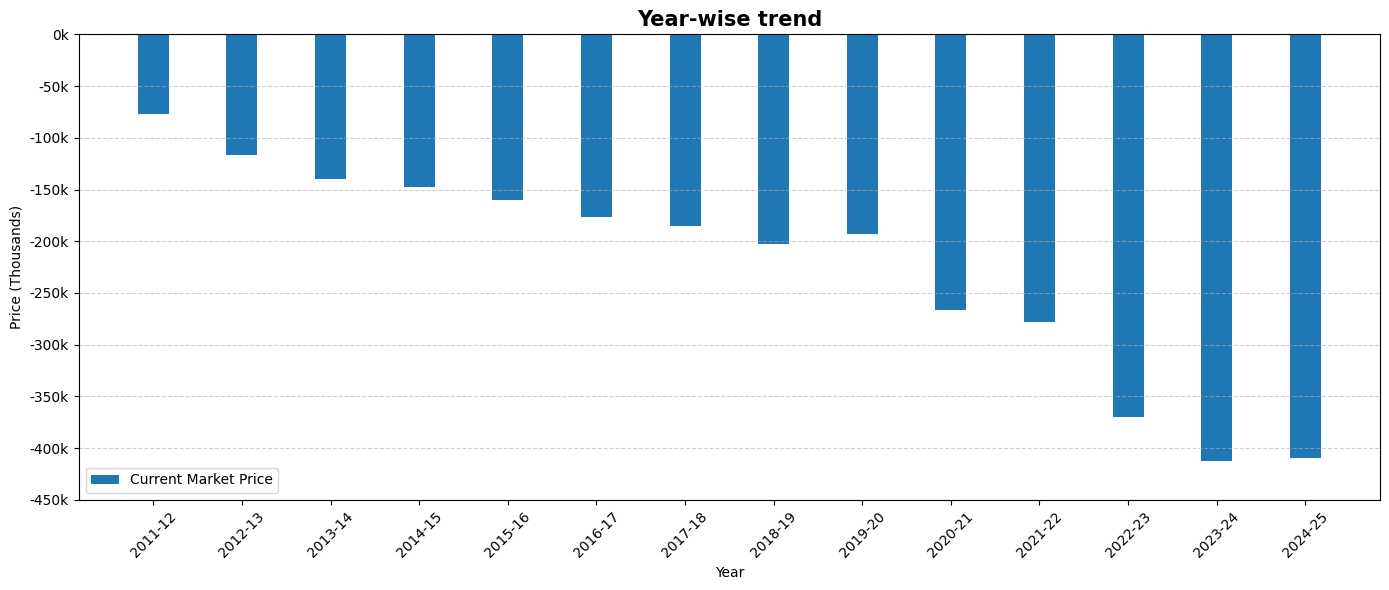

In [ ]:
x = np.arange(len(primary_income_receivable_df['year']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x, primary_income_receivable_df['current_price'], width, label='Current Market Price')
plt.xticks(x, primary_income_receivable_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])

plt.title("Year-wise trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Gross National Income Analysis

In [ ]:
GNI_df = annual_df[annual_df['indicator'] == 'Gross National Income']

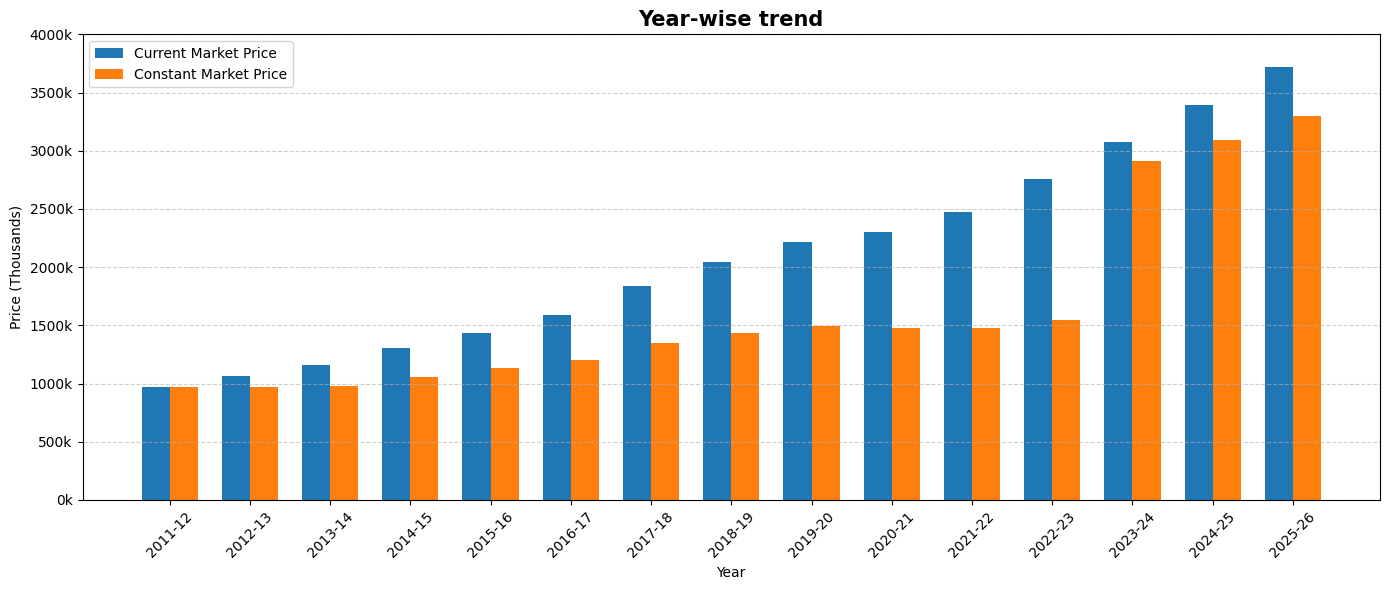

In [ ]:
x = np.arange(len(GNI_df['year']))
width = 0.35
plt.figure(figsize=(14,6))
plt.bar(x - width/2, government_final_consumption_expenditure_df['current_price'], width, label='Current Market Price')
plt.bar(x + width/2, government_final_consumption_expenditure_df['constant_price'], width, label='Constant Market Price')
plt.xticks(x, GNI_df['year'], rotation=45)
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.title("Year-wise trend", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Price (Thousands)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Inflation impact on industry and subindustries

In [ ]:
inflation_industry = annual_df.groupby(['industry'])['inflation_effect'].mean().sort_values(ascending=False)
inflation_subindustry = annual_df.groupby(['subindustry'])['inflation_effect'].mean().sort_values(ascending=False)

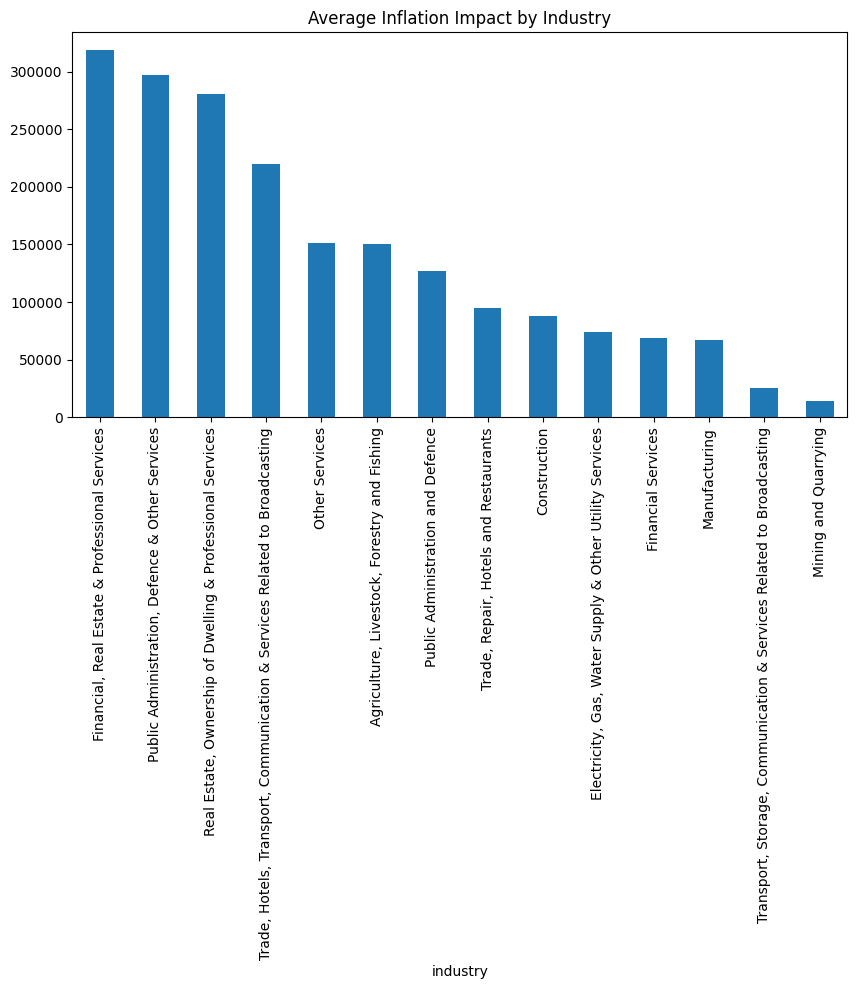

In [ ]:
inflation_industry.plot(kind='bar', figsize=(10,5))
plt.title("Average Inflation Impact by Industry")
plt.show()

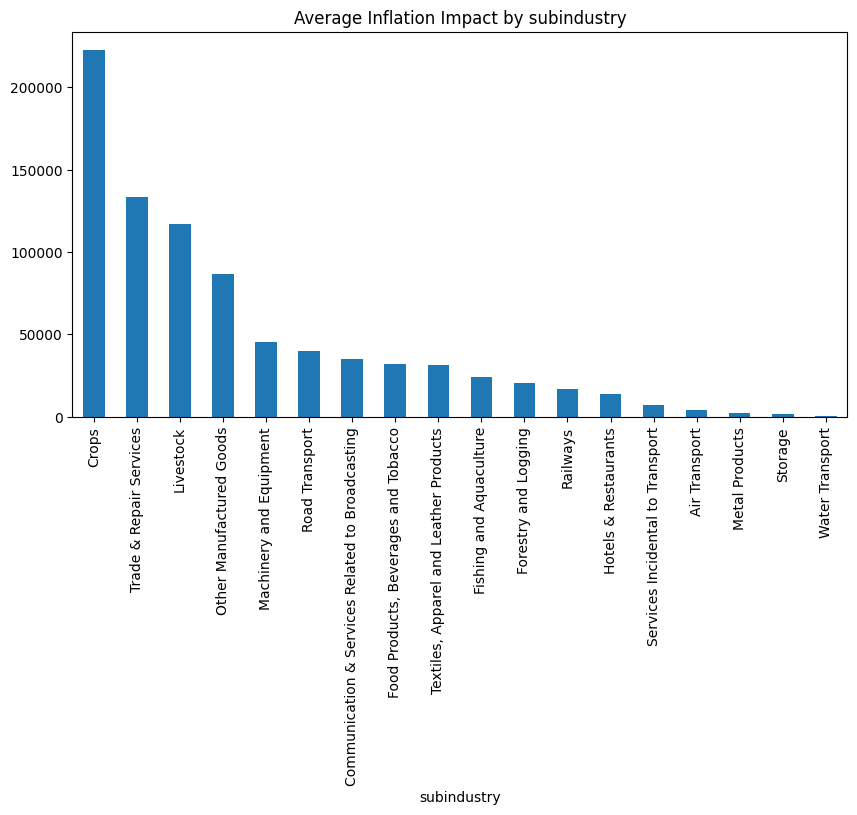

In [ ]:
inflation_subindustry.plot(kind='bar', figsize=(10,5))
plt.title("Average Inflation Impact by subindustry")
plt.show()

Global Capital formation trend analysis

In [ ]:
annual_df['indicator'] = annual_df['indicator'].str.strip()
gcf_df = annual_df[annual_df['indicator'].str.contains('Gross Capital Formation', case=False, na=False)]

In [ ]:
industry_trend = gcf_df.groupby(['year','industry'])['constant_price'].sum().reset_index()

In [ ]:
pivot_df = industry_trend.pivot(index='year', columns='industry', values='constant_price')

In [ ]:
pivot_df.head()

industry,"Agriculture, Livestock, Forestry and Fishing",Construction,"Electricity, Gas, Water Supply & Other Utility Services",Financial Services,Manufacturing,Mining and Quarrying,Other Services,Public Administration and Defence,"Real Estate, Ownership of Dwelling & Professional Services","Trade, Repair, Hotels and Restaurants","Transport, Storage, Communication & Services Related to Broadcasting"
year,,,,,,,,,,,
2011-12,547740.144380,232478.7753,308373.4110,42695.89731,615002.4867,67084.52606,150547.2930,248030.0000,816834.9258,384561.94313,517035.398600
2012-13,502187.643981,252825.2853,304329.2893,35323.63857,620148.2511,76312.15930,150009.4256,253810.5753,793221.5650,699546.21725,520948.931384
2013-14,568848.331439,164014.9475,298996.3409,35056.41219,584268.8721,133125.97700,175034.8825,276533.5150,849497.2385,425788.80404,621672.317177
2014-15,545326.257546,209917.9768,303064.8823,58331.74055,623915.1314,61017.92659,190614.4713,298355.9005,978131.0941,680621.99073,433048.117804
2015-16,475296.857610,215423.2110,370937.2708,62219.24379,695025.3376,49059.75728,230771.3540,346505.7223,833852.4895,723768.84799,656825.322413


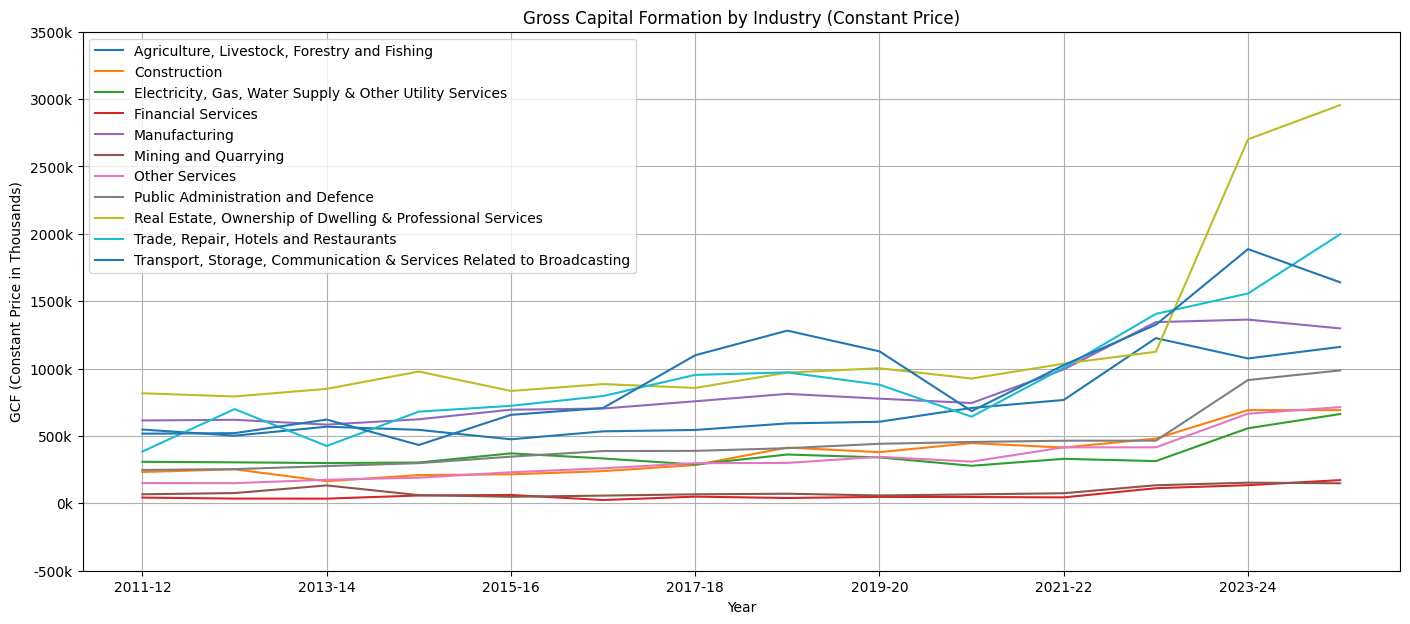

In [ ]:
pivot_df.plot(kind='line', figsize=(17,7))
plt.title('Gross Capital Formation by Industry (Constant Price)')
plt.xlabel('Year')
plt.ylabel('GCF (Constant Price in Thousands)')
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.legend()
plt.grid(True)
plt.show()

Percent Contribution of gcf in 2011-12

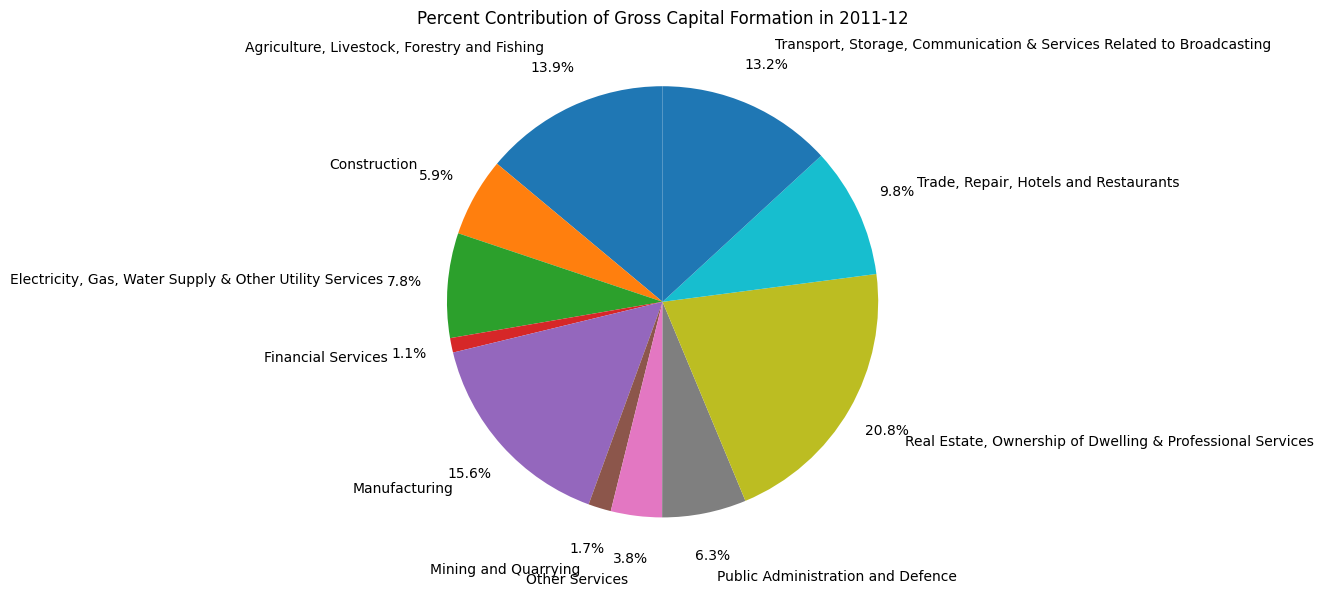

In [ ]:
plt.figure(figsize=(17,7))
plt.pie(pivot_df.loc['2011-12'], labels=pivot_df.columns, autopct='%1.1f%%', startangle=90,pctdistance=1.2, labeldistance=1.3)
plt.title('Percent Contribution of Gross Capital Formation in 2011-12')
plt.show()

Percentage contribution of GCF in 2024-25

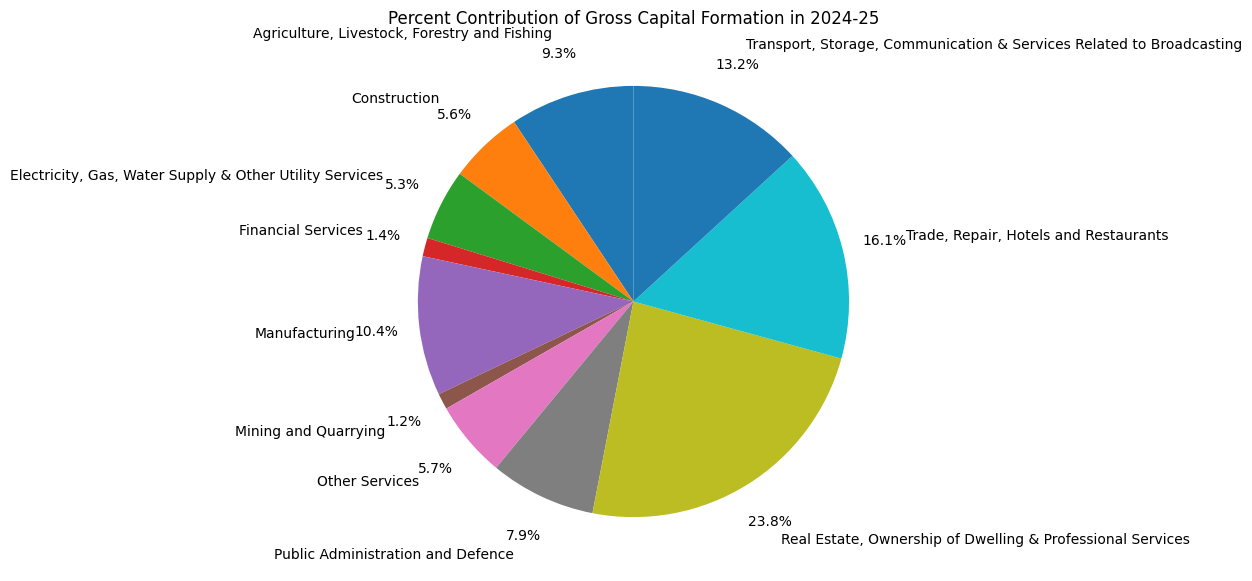

In [ ]:
plt.figure(figsize=(17,7))
plt.pie(pivot_df.loc['2024-25'], labels=pivot_df.columns, autopct='%1.1f%%', startangle=90,pctdistance=1.2, labeldistance=1.3)
plt.title('Percent Contribution of Gross Capital Formation in 2024-25')
plt.show()

Gross Fixed Capital Formation Analysis institutional sector wise

In [ ]:
annual_df['indicator'] = annual_df['indicator'].str.strip()
gfcf_df = annual_df[annual_df['indicator'].str.contains('Gross Fixed Capital Formation', case=False, na=False)]

In [ ]:
institutional_sector_trend = gfcf_df.groupby(['year','institutional_sector'])['constant_price'].sum().reset_index()

In [ ]:
pivot_1_df = institutional_sector_trend .pivot(index='year', columns='institutional_sector', values='constant_price')

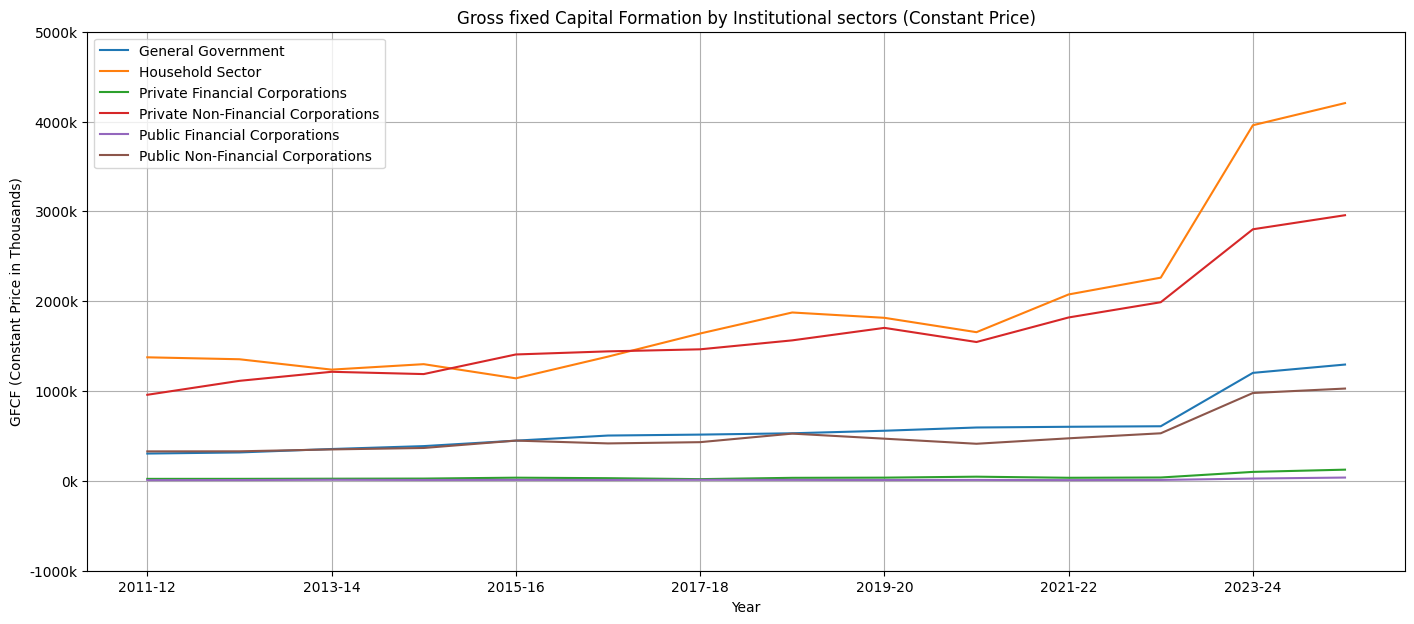

In [ ]:
pivot_1_df.plot(kind='line', figsize=(17,7))
plt.title('Gross fixed Capital Formation by Institutional sectors (Constant Price)')
plt.xlabel('Year')
plt.ylabel('GFCF (Constant Price in Thousands)')
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.legend()
plt.grid(True)
plt.show()

Gross Saving Analysis institutional sector wise

In [ ]:
annual_df['indicator'] = annual_df['indicator'].str.strip()
gross_saving_df = annual_df[annual_df['indicator'].str.contains('Gross Saving', case=False, na=False)]

In [ ]:
institutional_sector_trend_1 = gross_saving_df.groupby(['year','institutional_sector'])['current_price'].sum().reset_index()

In [ ]:
pivot_2_df = institutional_sector_trend_1 .pivot(index='year', columns='institutional_sector', values='current_price')

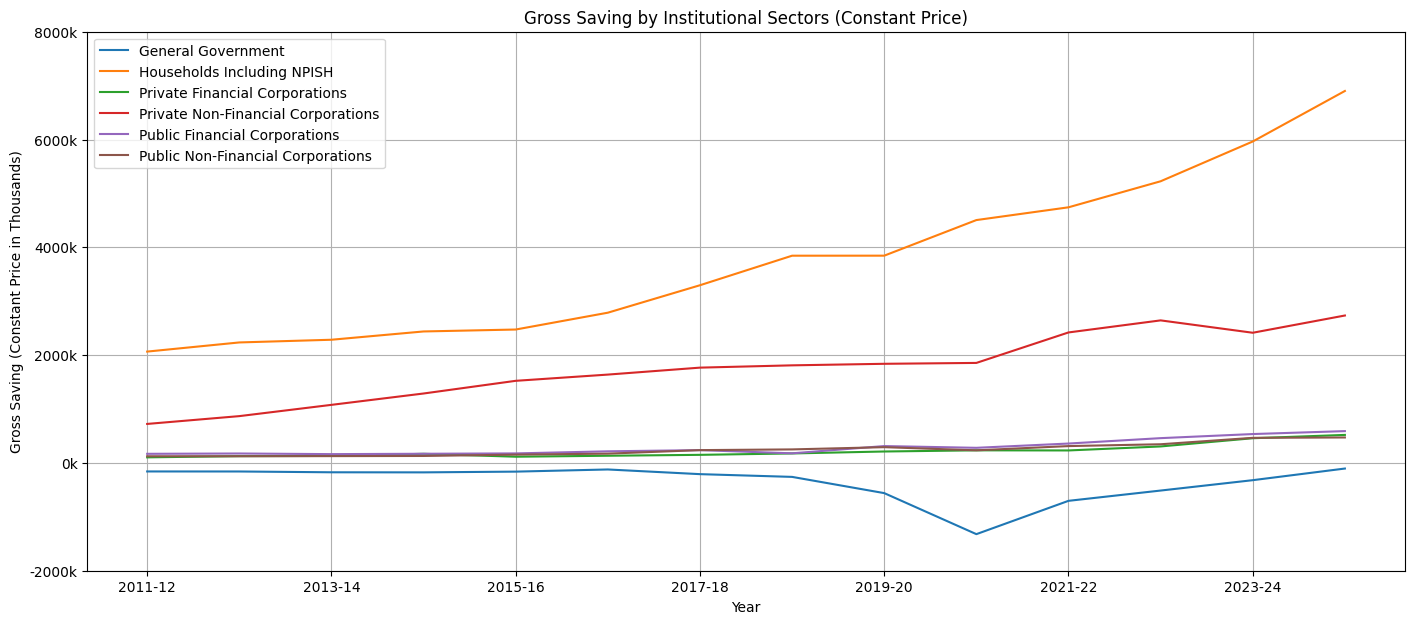

In [ ]:
pivot_2_df.plot(kind='line', figsize=(17,7))
plt.title('Gross Saving by Institutional Sectors (Constant Price)')
plt.xlabel('Year')
plt.ylabel('Gross Saving (Constant Price in Thousands)')
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.legend()
plt.grid(True)
plt.show()

Gross Value Added Analysis

1. Institutional level

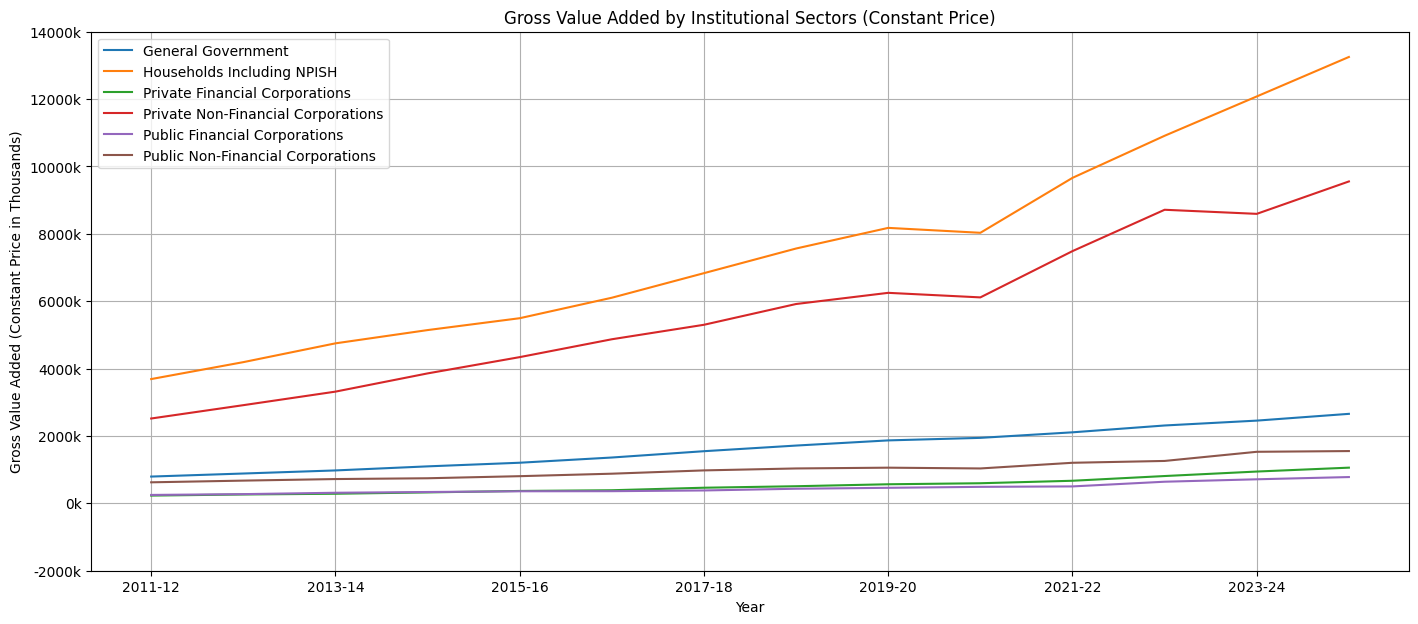

In [ ]:
gva_df = annual_df[annual_df['indicator'].str.contains('Gross Value Added', case=False, na=False)]
institutional_sector_trend_2 = gva_df.groupby(['year','institutional_sector'])['current_price'].sum().reset_index()
pivot_3_df = institutional_sector_trend_2.pivot(index='year', columns='institutional_sector', values='current_price')
pivot_3_df.plot(kind='line', figsize=(17,7))
plt.title('Gross Value Added by Institutional Sectors (Constant Price)')
plt.xlabel('Year')
plt.ylabel('Gross Value Added (Constant Price in Thousands)')
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.legend()
plt.grid(True)
plt.show()

2. Industry Level

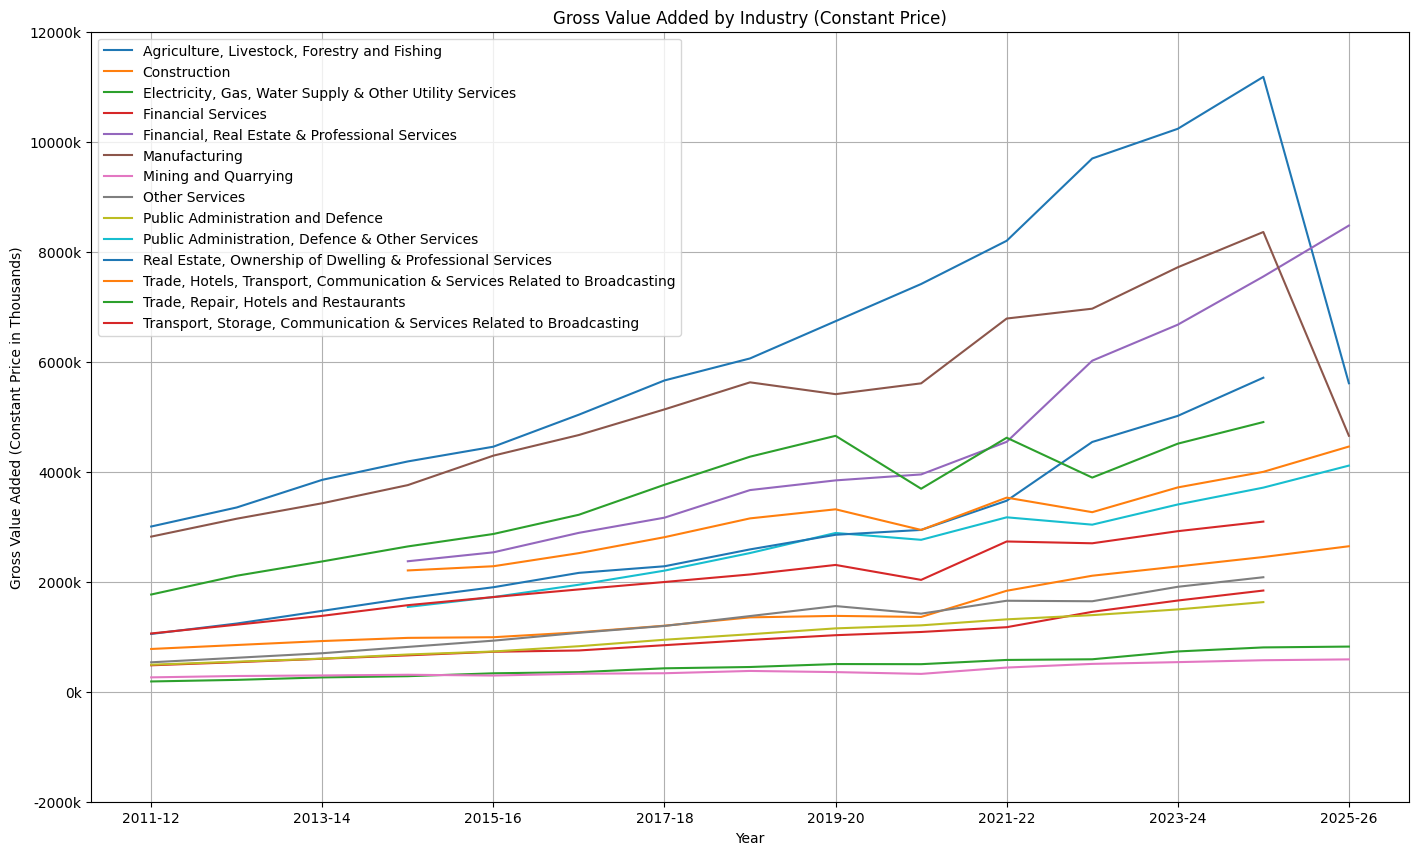

In [ ]:
gva_2_df = annual_df[annual_df['indicator'].str.contains('Gross Value Added', case=False, na=False)]
industry_sector_trend = gva_2_df.groupby(['year','industry'])['current_price'].sum().reset_index()
pivot_4_df = industry_sector_trend.pivot(index='year', columns='industry', values='current_price')
pivot_4_df.plot(kind='line', figsize=(17,10))
plt.title('Gross Value Added by Industry (Constant Price)')
plt.xlabel('Year')
plt.ylabel('Gross Value Added (Constant Price in Thousands)')
plt.yticks(ticks=plt.yticks()[0], labels=[f'{int(i/1e3)}k' for i in plt.yticks()[0]])
plt.legend()
plt.grid(True)
plt.show()

GVA Growth Rate Analysis

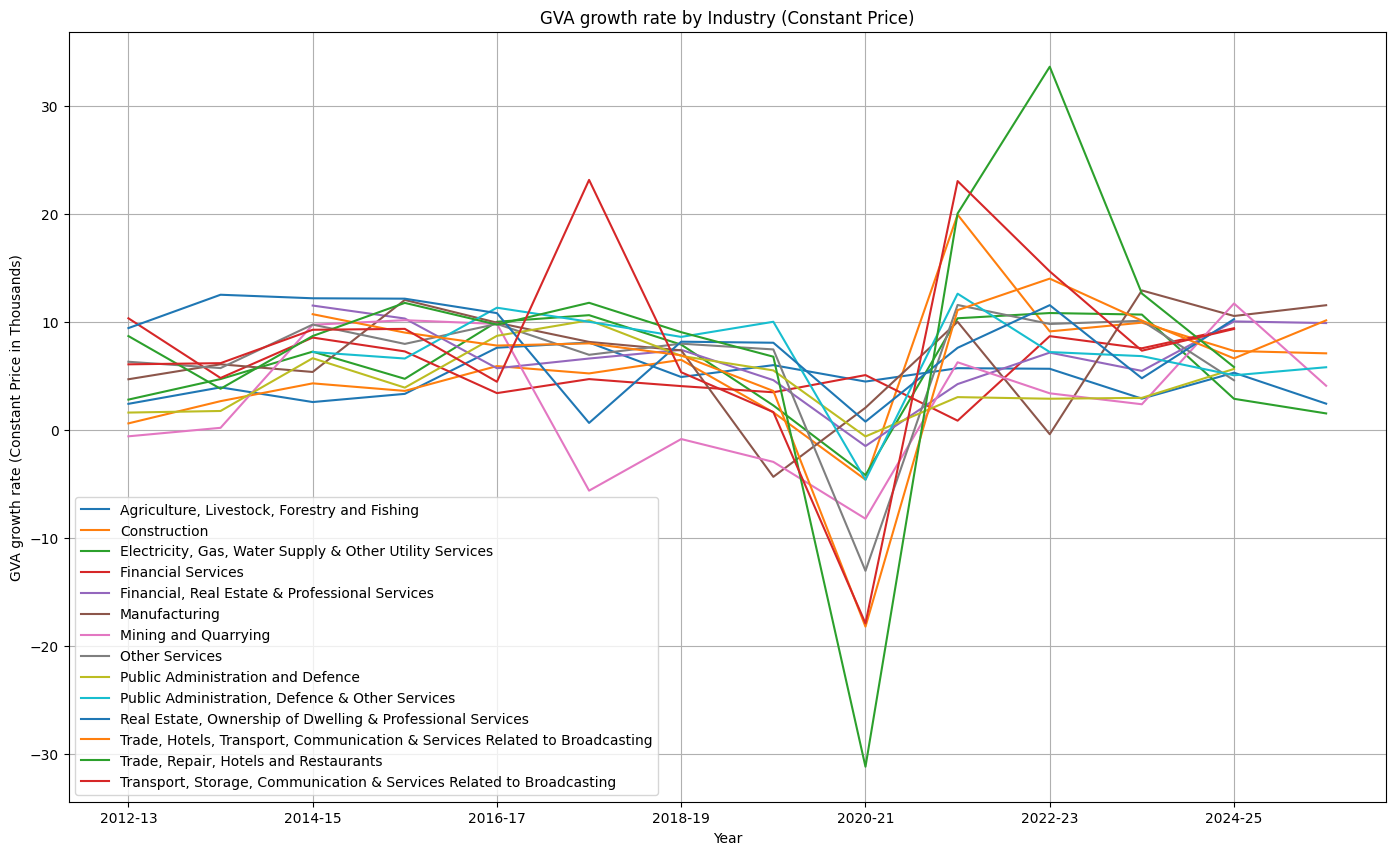

In [ ]:
gva_growth_rate_df = annual_df[annual_df['indicator'].str.contains('GVA Growth Rate', case=False, na=False)]
industry_sector_trend_2 = gva_growth_rate_df.groupby(['year','industry'])['constant_price'].mean().reset_index()
pivot_5_df = industry_sector_trend_2.pivot(index='year', columns='industry', values='constant_price')
pivot_5_df.plot(kind='line', figsize=(17,10))
plt.title('GVA growth rate by Industry (Constant Price)')
plt.xlabel('Year')
plt.ylabel('GVA growth rate (Constant Price in Thousands)')
plt.legend()
plt.grid(True)
plt.show()